In [23]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import os
import re
import tqdm
import pandas as pd
from scipy.optimize import brentq
from neml2.cli.inspect import main as inspect_main
import math

In [24]:
torch.manual_seed(0)

torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
device = torch.device(dev)

In [25]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=4.51):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.cached_solution = None
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading, cache=False):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder

        Keyword Args:
            cache (bool): if true, cache the solution and use it as a predictor for the next call.
                This heuristic can speed things up during inference where the model is called repeatedly with similar parameter values.
        """
        if cache and self.cached_solution is not None:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.FullTrajectoryPredictor(self.cached_solution),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=True
                ),
            )
        else:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.PreviousStepsPredictor(),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=True
                ),
            )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Pack the per-force raw tensors into the single flat forces tensor
        # pyzag consumes. ``assemble_forces`` uses the adapter's own force
        # layout, so the packing is guaranteed to match how the factory later
        # splits the tensor back apart (``_split_by_layout``); base sizes come
        # from the layout, so scalars need no trailing-1 unsqueeze here.
        forces = self.discrete_equations.assemble_forces(
            {
                "t": time,
                "temperature": temperature,
                "fixed_values": loading,
                "control": control,
            }
        )
        state0 = self.discrete_equations.assemble_state(
            {
                "mixed_state": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "log_rho_m": torch.full(
                    forces.shape[1:-1], math.log(self.initial_rho_m), device=forces.device
                ),
                "back_stress": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
            }
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        if cache:
            self.cached_solution = result.detach().clone()

        if not torch.isfinite(result).all():
            raise RuntimeError(
                "Non-finite state in the integrated solution: the solve produced NaN/Inf "
                "that pyzag's convergence test did not catch. Reduce nchunk or the step size."
            )

        return result[..., 0:1]

    def density(self, result):
        """Physical mobile dislocation density (um^{-2}) from a solved trajectory."""
        return torch.exp(result[..., 6:7])

In [26]:
nmodel = neml2.load_nonlinear_system("tungsten.i", "eq_sys")
nmodel.to(device=device)
pmodel = neml2.pyzag.NEML2PyzagModel(
    nmodel,
    include_parameters=[
        "v_disl_B_k",
        "v_disl_T_0",
        "v_disl_p",
        "v_disl_q",
        "v_disl_H_0",
        "rho_m_rate_k1",
        "rho_m_rate_k2_0",
        "rho_m_rate_Q_d",
        "kinharden_C",
        "kinharden_g",
    ],
)
neml2.compile(pmodel)

model = SolveStrain(pmodel, nchunk=10)
_ = inspect_main(["tungsten.i", "implicit_rate"])

Model: ComposedModel

Inputs (13):
  log_rho_m: type=Scalar
  control: type=SR2
  fixed_values: type=SR2
  mixed_state: type=SR2
  control~1: type=SR2
  fixed_values~1: type=SR2
  mixed_state~1: type=SR2
  temperature: type=Scalar
  t: type=Scalar
  t~1: type=Scalar
  back_stress: type=SR2
  back_stress~1: type=SR2
  log_rho_m~1: type=Scalar

Outputs (3):
  back_stress_residual: type=SR2
  log_rho_m_residual: type=Scalar
  stress_residual: type=SR2

Parameters (50):
  rho_m_from_log.scaling: dtype=torch.float64, device=cpu, shape=[]
  rho_m_from_log.rate: dtype=torch.float64, device=cpu, shape=[]
  E.a: dtype=torch.float64, device=cpu, shape=[]
  E.b: dtype=torch.float64, device=cpu, shape=[]
  E.c: dtype=torch.float64, device=cpu, shape=[]
  nu.a: dtype=torch.float64, device=cpu, shape=[]
  nu.b: dtype=torch.float64, device=cpu, shape=[]
  nu.c: dtype=torch.float64, device=cpu, shape=[]
  L.c_lath: dtype=torch.float64, device=cpu, shape=[]
  L.d_lath: dtype=torch.float64, device=cpu, 

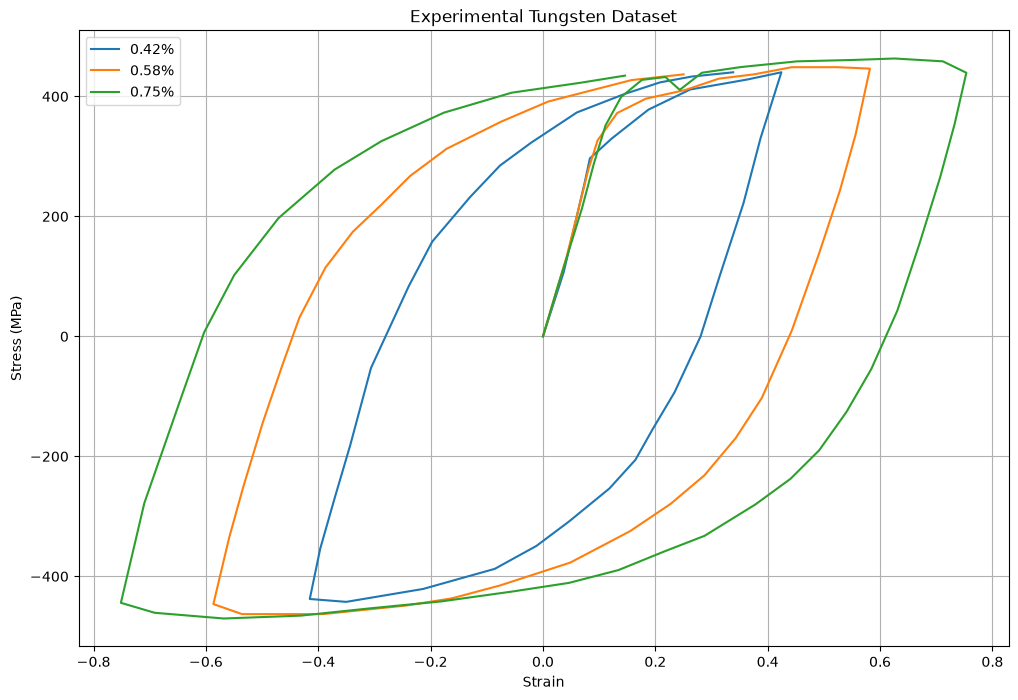

In [27]:
path = "cyclic_data"
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if "0.75" in filename:
            sr_label = "0.75"
        elif "0.58" in filename:
            sr_label = "0.58"
        elif "0.42" in filename:
            sr_label = "0.42"
        else:
            continue

        new_df = df.rename(columns={"x": f"{sr_label}_strain", "y": f"{sr_label}_stress"})
        data_frames[sr_label] = new_df
strain_data = {}
stress_data = {}

for sr_label, df in data_frames.items():
    strain_col = f"{sr_label}_strain"
    stress_col = f"{sr_label}_stress"
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[sr_label] = strain
    stress_data[sr_label] = stress

# Plot initial dataset
plt.figure(figsize=(12, 8))
for sr_label in strain_data:
    plt.plot(
        strain_data[sr_label].cpu().numpy(),
        stress_data[sr_label].cpu().numpy(),
        label=f"{sr_label}%",
    )
plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Experimental Tungsten Dataset")
plt.grid()
plt.legend()
plt.show()

In [28]:
n_cycles = 20
points_per_cycle = 200  # controls sharpness of triangle wave peaks

ntemperature = 1
nrate = 1
ntime = n_cycles * points_per_cycle  # total time steps
nbatch = 3
rates = torch.tensor([2.0e-3], device=device)
temperatures = torch.tensor([480.0], device=device)
ranges = torch.tensor([0.0042, 0.0058, 0.0075], device=device)

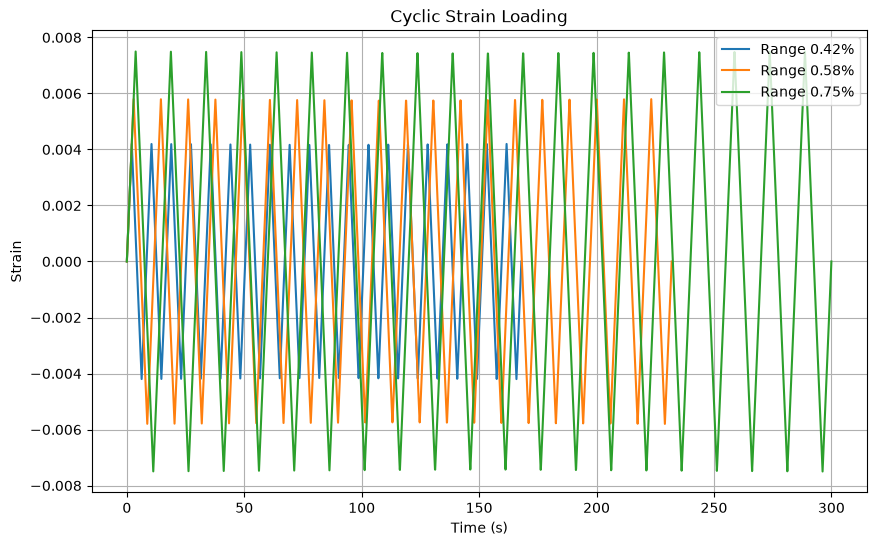


--- Full Input Tensors ---
time: torch.Size([4000, 3])
temperature: torch.Size([4000, 3])
loading: torch.Size([4000, 3, 6])


In [29]:
time = torch.zeros((ntime, nbatch), device=device)
temperature = torch.zeros((ntime, nbatch), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

plt.figure(figsize=(10, 6))
for i, s_range in enumerate(ranges):
    amplitude = s_range.item()
    period = 4.0 * s_range.item() / rates[0].item()
    total_time = n_cycles * period

    time_values = torch.linspace(0.0, total_time, ntime, device=device)

    strain_values = (2.0 * amplitude / torch.pi) * torch.arcsin(
        torch.sin(2.0 * torch.pi * time_values / period)
    )

    loading[:, i, 0] = strain_values
    time[:, i] = time_values
    temperature[:, i] = temperatures[0] + 273.15

    plt.plot(
        time_values.cpu().numpy(),
        strain_values.cpu().numpy(),
        label=f"Range {s_range.item() * 100:.2f}%",
    )

plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Cyclic Strain Loading")
plt.legend()
plt.grid()
plt.show()

print(
    f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}"
)

Initial data size for 0.42: torch.Size([37])
Initial data size for 0.58: torch.Size([45])
Initial data size for 0.75: torch.Size([47])
Interpolated data shape:
strain: torch.Size([4000, 3, 6])
stress: torch.Size([4000, 3, 6])


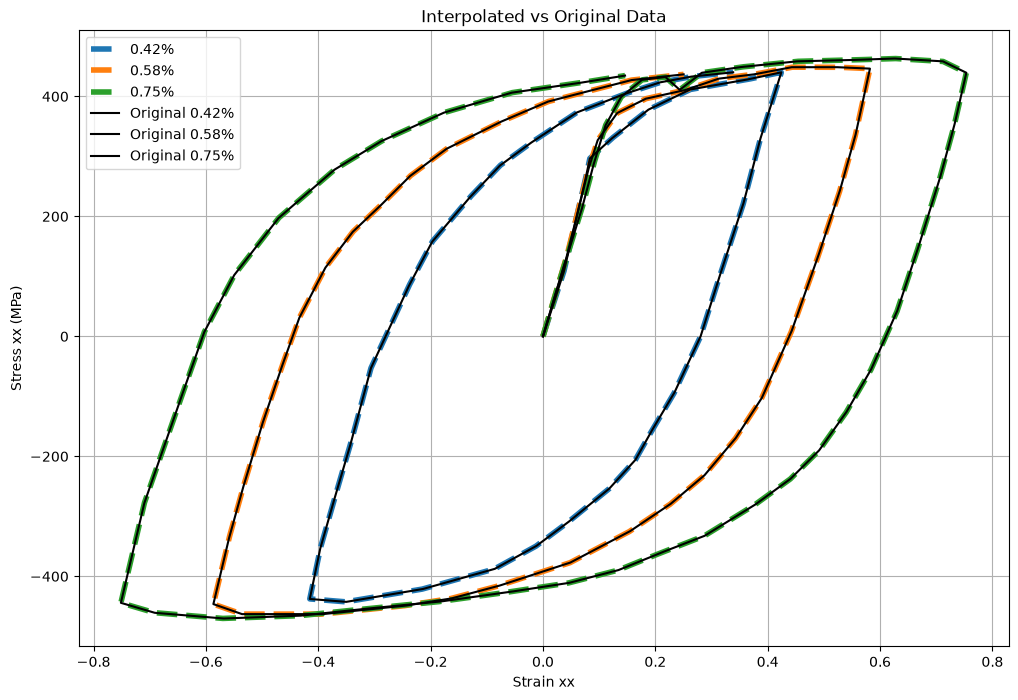

In [30]:
# Initial data shape
for sr_label in strain_data:
    print(f"Initial data size for {sr_label}: {stress_data[sr_label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, s_range in enumerate(ranges):
    sr_label = str(s_range.item() * 100)
    f_strain = torch.nn.functional.interpolate(
        strain_data[sr_label].unsqueeze(0).unsqueeze(0),
        size=ntime,
        mode="linear",
        align_corners=True,
    ).squeeze()
    f_stress = torch.nn.functional.interpolate(
        stress_data[sr_label].unsqueeze(0).unsqueeze(0),
        size=ntime,
        mode="linear",
        align_corners=True,
    ).squeeze()

    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

# Plot interpolated data
plt.figure(figsize=(12, 8))
for i, s_range in enumerate(ranges):
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        lw=4,
        label=f"{s_range.item() * 100}%",
    )
for sr_label in strain_data:
    plt.plot(
        strain_data[sr_label].cpu().numpy(),
        stress_data[sr_label].cpu().numpy(),
        color="k",
        label=f"Original {sr_label}%",
    )
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()

In [31]:
initial_params = {}
print("--- Before Reparameterization ---")
with torch.no_grad():
    for n, p in model.named_parameters():
        if p.dim() == 0:
            p.data = p.data.reshape(1)
        initial_params[n] = p.data.detach().clone()
        print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparameterization ---
discrete_equations.v_disl_B_k: tensor([8.3000e-11]), torch.Size([1])

discrete_equations.v_disl_T_0: tensor([3325.5000]), torch.Size([1])

discrete_equations.v_disl_p: tensor([0.6000]), torch.Size([1])

discrete_equations.v_disl_q: tensor([1.4000]), torch.Size([1])

discrete_equations.v_disl_H_0: tensor([2.5500]), torch.Size([1])

discrete_equations.kinharden_C: tensor([19000.]), torch.Size([1])

discrete_equations.kinharden_g: tensor([125.]), torch.Size([1])

discrete_equations.rho_m_rate_k1: tensor([5250.]), torch.Size([1])

discrete_equations.rho_m_rate_k2_0: tensor([525.]), torch.Size([1])

discrete_equations.rho_m_rate_Q_d: tensor([0.0110]), torch.Size([1])



In [32]:
with torch.no_grad():
    stress = model(time, temperature, loading)

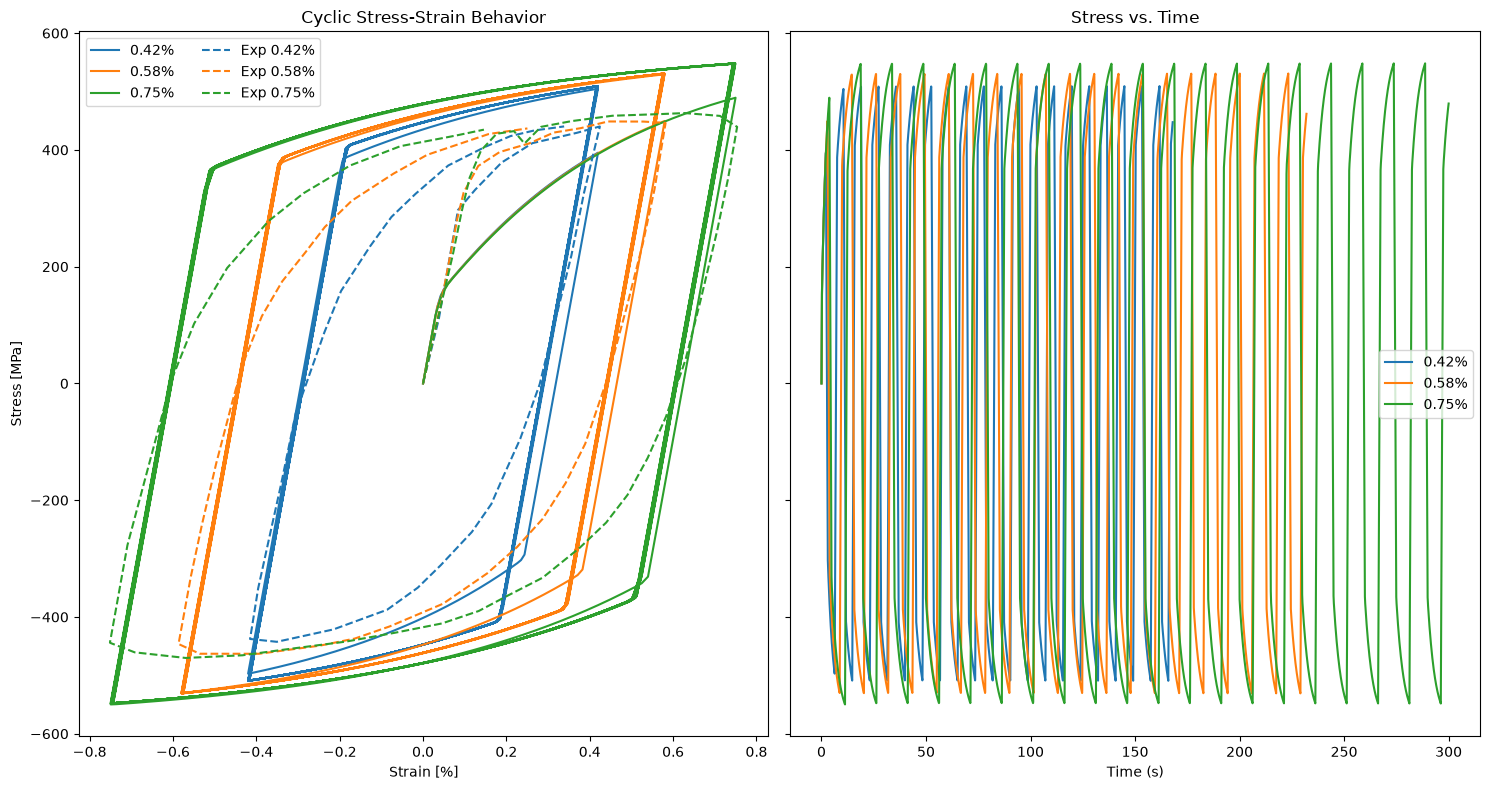

In [33]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(15, 8))
for i, s_range in enumerate(ranges):
    ax[0].plot(
        loading[:, i, 0].cpu().numpy() * 100,
        stress[:, i, 0].cpu().numpy(),
        color=f"C{i}",
        label=f"{s_range.item() * 100}%",
    )
for i, s_range in enumerate(ranges):
    ax[0].plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        color=f"C{i}",
        label=f"Exp {s_range.item() * 100}%",
    )
ax[0].set_xlabel("Strain [%]")
ax[0].set_ylabel("Stress [MPa]")
ax[0].set_title("Cyclic Stress-Strain Behavior")
ax[0].legend(ncol=2)
for i, s_range in enumerate(ranges):
    ax[1].plot(
        time[:, i].cpu().numpy(), stress[:, i, 0].cpu().numpy(), label=f"{s_range.item() * 100}%"
    )
ax[1].set_xlabel("Time (s)")
ax[1].set_title("Stress vs. Time")
ax[1].legend()
plt.tight_layout()
plt.show()

In [12]:
class LogRangeRescale(reparametrization.RangeRescale):
    """Map [0, 1] to [lb, ub] in log space, so an Adam step is a relative change."""

    def __init__(
        self,
        lb: torch.Tensor | float,
        ub: torch.Tensor | float,
        clamp: bool = True,
    ) -> None:
        super().__init__(lb, ub, clamp)
        self.lb = math.log(lb)
        self.ub = math.log(ub)
        self.clamp = clamp

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        if self.clamp:
            X = torch.clamp(X, 0, 1)

        return torch.exp(X * (self.ub - self.lb) + self.lb)

    def reverse(self, X: torch.Tensor) -> torch.Tensor:
        Y = (torch.log(X) - self.lb) / (self.ub - self.lb)

        if self.clamp:
            return torch.clamp(Y, 0, 1)

        return Y

In [13]:
Bk_scaler = LogRangeRescale(
    torch.tensor([1.0e-12], device=device), torch.tensor([1.0e-5], device=device)
)  # MPa*s
T_0_scaler = reparametrization.RangeRescale(
    torch.tensor([100.0], device=device), torch.tensor([5000.0], device=device)
)  # K
p_scaler = LogRangeRescale(torch.tensor([0.01], device=device), torch.tensor([10.0], device=device))
q_scaler = LogRangeRescale(torch.tensor([0.01], device=device), torch.tensor([10.0], device=device))
H0_scaler = reparametrization.RangeRescale(
    torch.tensor([0.1], device=device), torch.tensor([10.0], device=device)
)  # eV
C_scaler = LogRangeRescale(
    torch.tensor([100.0], device=device), torch.tensor([1.0e6], device=device)
)  # MPa
g_scaler = LogRangeRescale(torch.tensor([0.1], device=device), torch.tensor([1.0e4], device=device))
k1_scaler = LogRangeRescale(
    torch.tensor([100.0], device=device), torch.tensor([1.0e7], device=device)
)  # um^-1
k2_0_scaler = LogRangeRescale(
    torch.tensor([0.0001], device=device), torch.tensor([1.0e6], device=device)
)
Q_d_scaler = LogRangeRescale(
    torch.tensor([0.0001], device=device), torch.tensor([1.0], device=device)
)  # eV

model_reparameterizer = reparametrization.Reparameterizer(
    {
        "discrete_equations.v_disl_B_k": Bk_scaler,
        "discrete_equations.v_disl_T_0": T_0_scaler,
        "discrete_equations.v_disl_p": p_scaler,
        "discrete_equations.v_disl_q": q_scaler,
        "discrete_equations.v_disl_H_0": H0_scaler,
        "discrete_equations.kinharden_C": C_scaler,
        "discrete_equations.kinharden_g": g_scaler,
        "discrete_equations.rho_m_rate_k1": k1_scaler,
        "discrete_equations.rho_m_rate_k2_0": k2_0_scaler,
        "discrete_equations.rho_m_rate_Q_d": Q_d_scaler,
    },
    error_not_provided=True,
)
model_reparameterizer(model)
print(f"--- After Reparameterization ---")
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, requires_grad={p.requires_grad}")

--- After Reparameterization ---
discrete_equations.parametrizations.v_disl_B_k.original: tensor([0.2742]), requires_grad=True
discrete_equations.parametrizations.v_disl_T_0.original: tensor([0.6583]), requires_grad=True
discrete_equations.parametrizations.v_disl_p.original: tensor([0.5927]), requires_grad=True
discrete_equations.parametrizations.v_disl_q.original: tensor([0.7154]), requires_grad=True
discrete_equations.parametrizations.v_disl_H_0.original: tensor([0.2475]), requires_grad=True
discrete_equations.parametrizations.kinharden_C.original: tensor([0.5697]), requires_grad=True
discrete_equations.parametrizations.kinharden_g.original: tensor([0.6194]), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k1.original: tensor([0.3440]), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k2_0.original: tensor([0.6720]), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_Q_d.original: tensor([0.5103]), requires_grad=True


In [14]:
niter = 1500

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.1,
    patience=150,
    threshold=1e-4,
)
loss_fn = torch.nn.MSELoss(reduction="mean")

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []

peak_stress = exp_stress_data[-1, :, 0:1].detach()
for i in titer:
    optimizer.zero_grad()
    res = model(time, temperature, loading)
    res_norm = res / (peak_stress + 1e-8)
    exp_norm = exp_stress_data[..., 0:1] / (peak_stress + 1e-8)
    loss = loss_fn(res_norm, exp_norm)

    # --- Bug fix: guard BEFORE backward ---
    if not torch.isfinite(loss) or loss.item() > 1e6:
        titer.set_description(f"Loss: [SKIP bad solve @ iter {i}]")
        continue  # skip backward + step entirely

    loss.backward()
    optimizer.step()
    scheduler.step(loss)

    loss_history.append(loss.detach().clone().cpu())
    titer.set_description("Loss: %3.2e" % loss_history[-1])

# --- Plots ---
plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.title("Loss history")

plt.figure()
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Loss history (linear scale)")
plt.show()

Loss:: :   0%|          |0/1500/opt/anaconda3/envs/neml2/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1691: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  current = float(metrics)
Loss: 6.45e-01: :  12%|█▏        |185/1500


KeyboardInterrupt: 